<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/av_msf_audio_visual_sound_field.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# [CELL 1 - Setup Environment and Install Dependencies]
import os
import sys
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional, Set

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import librosa
import librosa.display
from IPython.display import Audio, display

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Compute Device: {device}")
print("Environment successfully initialized.")

Using Compute Device: cpu
Environment successfully initialized.


In [2]:
# [CELL 2 - Synthetic 3D Surface & Physical Impact Sound Generator]

class SyntheticObjectSurface:
    """
    Simulates a 3D object surface grid with 3D positions x in R^3
    and dense 3D visual feature embeddings (simulating 3D Gaussian Splatting features).
    """
    def __init__(self, grid_res: int = 20, feat_dim: int = 16):
        self.grid_res = grid_res
        self.feat_dim = feat_dim

        # Create 2D/3D surface grid (x, y, z)
        x = np.linspace(-1.0, 1.0, grid_res)
        y = np.linspace(-1.0, 1.0, grid_res)
        xx, yy = np.meshgrid(x, y)
        zz = 0.2 * np.sin(np.pi * xx) * np.cos(np.pi * yy)  # Curved surface

        self.points = np.stack([xx.flatten(), yy.flatten(), zz.flatten()], axis=-1)  # (N, 3)

        # Generate spatial visual features for points
        np.random.seed(100)
        self.visual_features = np.random.randn(len(self.points), feat_dim).astype(np.float32)

class GroundTruthModalSoundField:
    """
    Generates synthetic ground truth impact sounds using physical modal synthesis:
    S(x, t) = Sum_k a_k(x) * exp(-gamma_k * t) * sin(2 * pi * f_k * t)
    """
    def __init__(self, num_modes: int = 8, sample_rate: int = 16000, duration: float = 0.5):
        self.K = num_modes
        self.sr = sample_rate
        self.duration = duration
        self.t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False, dtype=np.float32)

        # Ground truth modal frequencies (Hz) and dampings (1/s)
        self.gt_freqs = np.array([220.0, 440.0, 880.0, 1250.0, 1750.0, 2300.0, 3100.0, 4200.0], dtype=np.float32)
        self.gt_dampings = np.array([8.0, 12.0, 18.0, 25.0, 35.0, 45.0, 60.0, 80.0], dtype=np.float32)

    def compute_mode_amplitudes(self, points: np.ndarray) -> np.ndarray:
        """Position-dependent mode shape gains a_k(x)."""
        N = len(points)
        amps = np.zeros((N, self.K), dtype=np.float32)
        for k in range(self.K):
            # Spatial mode shapes (standing wave pattern over surface)
            freq_factor = (k + 1) * 0.5
            amps[:, k] = np.abs(np.sin(freq_factor * np.pi * points[:, 0]) * np.cos(freq_factor * np.pi * points[:, 1]))
        return amps

    def synthesize_impact_sound(self, points: np.ndarray) -> np.ndarray:
        """Renders raw audio waveforms for impact locations."""
        amps = self.compute_mode_amplitudes(points)  # (N, K)
        N = len(points)
        L = len(self.t)
        waveforms = np.zeros((N, L), dtype=np.float32)

        for i in range(N):
            sound = np.zeros(L, dtype=np.float32)
            for k in range(self.K):
                env = np.exp(-self.gt_dampings[k] * self.t)
                sine = np.sin(2.0 * np.pi * self.gt_freqs[k] * self.t)
                sound += amps[i, k] * env * sine
            # Normalize waveform
            if np.max(np.abs(sound)) > 0:
                sound = sound / np.max(np.abs(sound))
            waveforms[i] = sound

        return waveforms

# Setup surface and ground truth data generator
obj_surface = SyntheticObjectSurface(grid_res=20)
gt_sound_field = GroundTruthModalSoundField(num_modes=8)

gt_waveforms = gt_sound_field.synthesize_impact_sound(obj_surface.points)
print(f"Surface generated: {len(obj_surface.points)} 3D points.")
print(f"Ground Truth Impact Audio: {gt_waveforms.shape[0]} locations, {gt_waveforms.shape[1]} audio samples each @ 16kHz.")

Surface generated: 400 3D points.
Ground Truth Impact Audio: 400 locations, 8000 audio samples each @ 16kHz.


In [5]:
# [CELL 3 - AV-MSF Network & Differentiable Modal Audio Renderer]

class SpatialModeShapeMLP(nn.Module):
    """
    MLP that maps 3D point coordinates + visual features to spatial mode amplitudes a_k(x).
    """
    def __init__(self, in_dim: int = 19, num_modes: int = 8, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_modes),
            nn.Softplus()  # Ensures positive mode amplitudes
        )

    def forward(self, x_coords: torch.Tensor, v_feats: torch.Tensor) -> torch.Tensor:
        inputs = torch.cat([x_coords, v_feats], dim=-1)
        return self.net(inputs)

class AudioVisualModalSoundField(nn.Module):
    """
    AV-MSF Model: Combines learnable global modal parameters (frequencies, dampings)
    with spatial mode shape field network a_k(x).
    """
    def __init__(self, num_modes: int = 8, feat_dim: int = 16, sample_rate: int = 16000, duration: float = 0.5):
        super().__init__()
        self.K = num_modes
        self.sr = sample_rate
        self.duration = duration

        # Learnable global frequencies (f_k) and dampings (gamma_k) initialized near spectrum
        init_freqs = torch.linspace(150.0, 4000.0, num_modes)
        init_dampings = torch.ones(num_modes) * 30.0

        self.freq_params = nn.Parameter(torch.log(init_freqs))
        self.damping_params = nn.Parameter(torch.log(init_dampings))

        # Spatial Mode Shape Network
        self.mode_mlp = SpatialModeShapeMLP(in_dim=3 + feat_dim, num_modes=num_modes)

    def get_modal_parameters(self) -> Tuple[torch.Tensor, torch.Tensor]:
        freqs = torch.exp(self.freq_params)
        dampings = torch.exp(self.damping_params)
        return freqs, dampings

    def forward(self, x_coords: torch.Tensor, v_feats: torch.Tensor, time_vec: torch.Tensor) -> torch.Tensor:
        """
        Differentiable modal synthesis render:
        Synthesizes waveform S(x, t) for impact locations x.
        """
        N = x_coords.shape[0]
        L = time_vec.shape[0]

        freqs, dampings = self.get_modal_parameters()  # (K,)
        amps = self.mode_mlp(x_coords, v_feats)         # (N, K)

        # Reshape for broadcasted modal summation
        # time_vec: (1, 1, L), freqs: (1, K, 1), dampings: (1, K, 1), amps: (N, K, 1)
        t = time_vec.view(1, 1, L)
        f = freqs.view(1, self.K, 1)
        g = dampings.view(1, self.K, 1)
        a = amps.unsqueeze(-1)

        # S_k(x, t) = a_k(x) * exp(-gamma_k * t) * sin(2 * pi * f_k * t)
        envelopes = torch.exp(-g * t)
        oscillations = torch.sin(2.0 * math.pi * f * t)
        modal_components = a * envelopes * oscillations  # (N, K, L)

        rendered_waveforms = torch.sum(modal_components, dim=1)  # (N, L)
        return rendered_waveforms

print("AV-MSF PyTorch Architecture successfully defined.")

AV-MSF PyTorch Architecture successfully defined.


In [6]:
# [CELL 4 - Multi-Resolution STFT Loss & Few-Shot Training Split]

class MultiResolutionSTFTLoss(nn.Module):
    """
    Multi-resolution Short-Time Fourier Transform (STFT) spectral loss
    to optimize synthesized impact sounds against acoustic recordings.
    """
    def __init__(self, fft_sizes=[256, 512, 1024], hop_sizes=[64, 128, 256], win_lengths=[256, 512, 1024]):
        super().__init__()
        self.fft_sizes = fft_sizes
        self.hop_sizes = hop_sizes
        self.win_lengths = win_lengths

    def stft_loss(self, x: torch.Tensor, y: torch.Tensor, n_fft: int, hop_length: int, win_length: int) -> torch.Tensor:
        window = torch.hann_window(win_length).to(x.device)

        stft_x = torch.stft(x, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window, return_complex=True)
        stft_y = torch.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window, return_complex=True)

        mag_x = torch.abs(stft_x) + 1e-7
        mag_y = torch.abs(stft_y) + 1e-7

        # Spectral convergence loss + Log STFT magnitude loss
        sc_loss = torch.norm(mag_y - mag_x, p="fro") / (torch.norm(mag_y, p="fro") + 1e-7)
        log_loss = F.l1_loss(torch.log(mag_x), torch.log(mag_y))

        return sc_loss + log_loss

    def forward(self, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        total_loss = 0.0
        for n_fft, hop, win in zip(self.fft_sizes, self.hop_sizes, self.win_lengths):
            total_loss += self.stft_loss(x, y, n_fft, hop, win)
        return total_loss / len(self.fft_sizes)

# Select Few-Shot Training Points (5 impact audio recordings out of 400 surface points)
num_total_points = len(obj_surface.points)
few_shot_indices = np.random.choice(num_total_points, size=5, replace=False)
test_indices = np.array([i for i in range(num_total_points) if i not in few_shot_indices])

# Prepare Tensors
train_points = torch.tensor(obj_surface.points[few_shot_indices], dtype=torch.float32).to(device)
train_feats = torch.tensor(obj_surface.visual_features[few_shot_indices], dtype=torch.float32).to(device)
train_audio = torch.tensor(gt_waveforms[few_shot_indices], dtype=torch.float32).to(device)

test_points = torch.tensor(obj_surface.points[test_indices], dtype=torch.float32).to(device)
test_feats = torch.tensor(obj_surface.visual_features[test_indices], dtype=torch.float32).to(device)
test_audio = torch.tensor(gt_waveforms[test_indices], dtype=torch.float32).to(device)

time_vec = torch.tensor(gt_sound_field.t, dtype=torch.float32).to(device)

print(f"Few-Shot Training Setup: {len(few_shot_indices)} recorded impact points used for optimization.")
print(f"Unseen Testing Setup: {len(test_indices)} novel contact points reserved for evaluation.")

Few-Shot Training Setup: 5 recorded impact points used for optimization.
Unseen Testing Setup: 395 novel contact points reserved for evaluation.


In [7]:
# [CELL 5 - Optimization Loop: Reconstructing AV-MSF from Sparse Impacts]

av_msf_model = AudioVisualModalSoundField(num_modes=8, feat_dim=16).to(device)
stft_criterion = MultiResolutionSTFTLoss().to(device)

optimizer = optim.Adam(av_msf_model.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

num_epochs = 300
loss_history = []
test_loss_history = []

print("\n--- Starting AV-MSF Few-Shot Reconstruction Optimization ---")
start_time = time.time()

for epoch in range(1, num_epochs + 1):
    av_msf_model.train()
    optimizer.zero_grad()

    # Synthesize audio for sparse training impact points
    pred_train_waveforms = av_msf_model(train_points, train_feats, time_vec)

    # Multi-resolution STFT loss against recordings
    loss = stft_criterion(pred_train_waveforms, train_audio)
    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())

    # Evaluate on unseen novel contact points
    if epoch % 50 == 0 or epoch == 1:
        av_msf_model.eval()
        with torch.no_grad():
            pred_test_waveforms = av_msf_model(test_points, test_feats, time_vec)
            test_loss = stft_criterion(pred_test_waveforms, test_audio).item()
            test_loss_history.append((epoch, test_loss))

        print(f"Epoch {epoch:03d}/{num_epochs} | Train Spectral Loss: {loss.item():.4f} | Novel Point Render Loss: {test_loss:.4f}")

elapsed_time = time.time() - start_time
print(f"\nOptimization completed in {elapsed_time:.2f} seconds.")


--- Starting AV-MSF Few-Shot Reconstruction Optimization ---
Epoch 001/300 | Train Spectral Loss: 5.5501 | Novel Point Render Loss: 5.1259
Epoch 050/300 | Train Spectral Loss: 2.7398 | Novel Point Render Loss: 2.9564
Epoch 100/300 | Train Spectral Loss: 2.3628 | Novel Point Render Loss: 2.7066
Epoch 150/300 | Train Spectral Loss: 2.2336 | Novel Point Render Loss: 2.6249
Epoch 200/300 | Train Spectral Loss: 2.0841 | Novel Point Render Loss: 2.5112
Epoch 250/300 | Train Spectral Loss: 2.0408 | Novel Point Render Loss: 2.5063
Epoch 300/300 | Train Spectral Loss: 2.0256 | Novel Point Render Loss: 2.4908

Optimization completed in 22.63 seconds.



--- Modal Parameters Estimation Evaluation ---
Ground Truth Frequencies (Hz): [ 220.  440.  880. 1250. 1750. 2300. 3100. 4200.]
Reconstructed Frequencies (Hz): [ 139.6  620.1 1112.  1750.1 2299.2 3099.9 3377.3 4200. ]


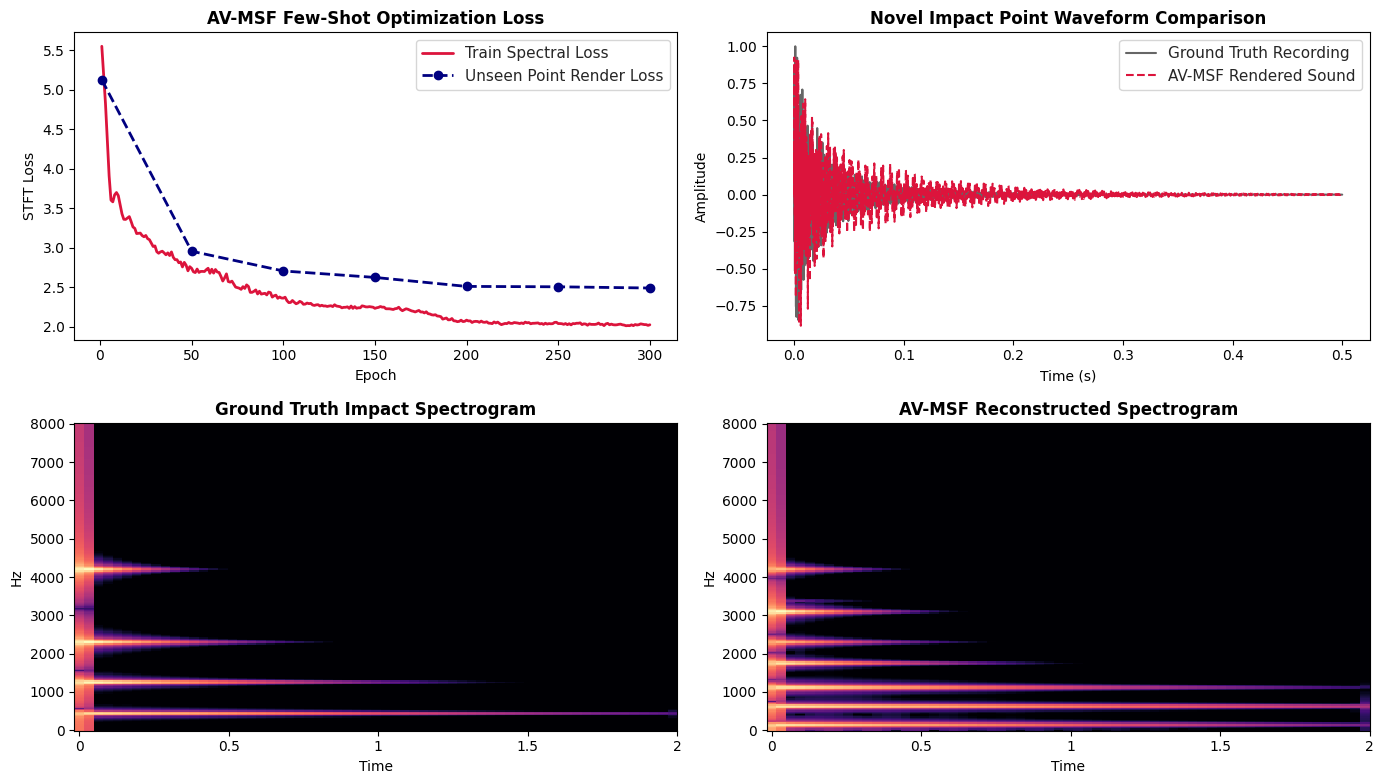


--- Playback Audio Demos ---
1. Ground Truth Impact Sound:


2. AV-MSF Rendered Impact Sound (Novel Location):


3. Object Sound Editing (Material Stiffness Shift):


In [8]:
# [CELL 6 - Visualization, Novel Sound Rendering & Sound Editing Demo]

# 1. Print Frequency Estimation Accuracy
est_freqs, est_dampings = av_msf_model.get_modal_parameters()
est_freqs_np = np.sort(est_freqs.detach().cpu().numpy())
gt_freqs_np = np.sort(gt_sound_field.gt_freqs)

print("\n--- Modal Parameters Estimation Evaluation ---")
print(f"Ground Truth Frequencies (Hz): {np.round(gt_freqs_np, 1)}")
print(f"Reconstructed Frequencies (Hz): {np.round(est_freqs_np, 1)}")

# 2. Render Sound at a Novel Contact Point & Perform Sound Editing (Material Shift)
av_msf_model.eval()
with torch.no_grad():
    sample_idx = 10
    novel_pt = test_points[sample_idx:sample_idx+1]
    novel_ft = test_feats[sample_idx:sample_idx+1]

    # Standard Novel Render
    rendered_audio = av_msf_model(novel_pt, novel_ft, time_vec).cpu().numpy().squeeze()
    target_gt_audio = test_audio[sample_idx].cpu().numpy()

    # Material Sound Editing Demo: Scale dampings to simulate wood vs metal stiffness shift
    freqs, dampings = av_msf_model.get_modal_parameters()
    # Stiffer material simulation (higher pitch, longer decay)
    edited_freqs = freqs * 1.5
    edited_dampings = dampings * 0.3

    amps = av_msf_model.mode_mlp(novel_pt, novel_ft)
    t = time_vec.view(1, 1, -1)
    f = edited_freqs.view(1, -1, 1)
    g = edited_dampings.view(1, -1, 1)
    a = amps.unsqueeze(-1)
    edited_audio = torch.sum(a * torch.exp(-g * t) * torch.sin(2.0 * math.pi * f * t), dim=1).cpu().numpy().squeeze()

# 3. Plot Results
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Plot Loss Curve
axes[0, 0].plot(range(1, num_epochs + 1), loss_history, color='crimson', linewidth=2, label="Train Spectral Loss")
ep_x, val_y = zip(*test_loss_history)
axes[0, 0].plot(ep_x, val_y, 'o--', color='navy', linewidth=2, label="Unseen Point Render Loss")
axes[0, 0].set_title("AV-MSF Few-Shot Optimization Loss", fontweight='bold')
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("STFT Loss")
axes[0, 0].legend()

# Plot Waveform Comparison
axes[0, 1].plot(gt_sound_field.t, target_gt_audio, label="Ground Truth Recording", color="black", alpha=0.6)
axes[0, 1].plot(gt_sound_field.t, rendered_audio, label="AV-MSF Rendered Sound", color="crimson", linestyle="--")
axes[0, 1].set_title("Novel Impact Point Waveform Comparison", fontweight='bold')
axes[0, 1].set_xlabel("Time (s)")
axes[0, 1].set_ylabel("Amplitude")
axes[0, 1].legend()

# Plot Spectrogram Comparison
D_gt = librosa.amplitude_to_db(np.abs(librosa.stft(target_gt_audio, n_fft=512)), ref=np.max)
D_pred = librosa.amplitude_to_db(np.abs(librosa.stft(rendered_audio, n_fft=512)), ref=np.max)

librosa.display.specshow(D_gt, sr=16000, x_axis='time', y_axis='hz', ax=axes[1, 0], cmap='magma')
axes[1, 0].set_title("Ground Truth Impact Spectrogram", fontweight='bold')

librosa.display.specshow(D_pred, sr=16000, x_axis='time', y_axis='hz', ax=axes[1, 1], cmap='magma')
axes[1, 1].set_title("AV-MSF Reconstructed Spectrogram", fontweight='bold')

plt.tight_layout()
plt.savefig("av_msf_reconstruction_benchmark.png", dpi=300)
plt.show()

print("\n--- Playback Audio Demos ---")
print("1. Ground Truth Impact Sound:")
display(Audio(target_gt_audio, rate=16000))
print("2. AV-MSF Rendered Impact Sound (Novel Location):")
display(Audio(rendered_audio, rate=16000))
print("3. Object Sound Editing (Material Stiffness Shift):")
display(Audio(edited_audio, rate=16000))